# Pulsed ODMR

Optically detected magnetic resonance (ODMR) is the most basic NV measurement: the electron spin is
optically initialized, a microwave pulse at some frequency $f$ is applied, and the population left in
the $m_S=0$ electron spin state is read out optically. Sweeping $f$ traces out a resonance spectrum
&mdash; this is usually the very first measurement in any NV experiment, since it locates the resonance
frequencies that every other pulse sequence (Rabi, Ramsey, ...) depends on.

In **pulsed** ODMR, the microwave pulse has a fixed, finite duration $\tau$, applied with the laser off
(unlike **continuous-wave** ODMR, where laser and microwave are on simultaneously). Simphony does not
currently model the optical initialization/readout physics directly, so reading out the population in
$m_S=0$ simply means evaluating the $m_S=0$ population at the end of the pulse.

A real ODMR measurement does not initialize the nuclear spin state between shots &mdash; it is
effectively thermally unpolarized. Rather than assuming one fixed nuclear spin projection, we capture
this by initializing the model in a mixed state via `Model.initial_density_matrix`. With the
$^{14}\mathrm{N}$ nuclear spin, this naturally produces the classic **hyperfine-resolved triplet**:
three resonance dips, one per nuclear spin projection $m_I$, each broadened by the pulse's finite
duration.

We assume familiarity with the components, pulses, and simulation workflow introduced in the basic
tutorial.

## Import the packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import simphony

simphony.Config.set_platform('cpu')
simphony.Config.set_matplotlib_format('retina')

## Model

We use the electron + $^{14}\mathrm{N}$ system (dimension 3 nuclear spin, spin projection $m_I \in \{-1, 0, +1\}$), which has default `MW_x`/`RF_x` driving fields already attached. The model's built-in hyperfine splitting ($2.14$ MHz) is close to the $2.16$ MHz value measured by Dréau *et al.*, ["Avoiding power broadening in optically detected magnetic resonance of single NV defects for enhanced dc magnetic field sensitivity"](https://arxiv.org/abs/1108.0178), Phys. Rev. B **84**, 195204 (2011), for a real $^{14}\mathrm{N}$ NV defect:

In [2]:
model = simphony.default_nv_model(nitrogen_isotope=14)
model

Model(spin_names=['e', 'N'], num_static_fields=1, driving_field_names=['MW_x', 'RF_x'], dimension=9)

## A thermally unpolarized nuclear spin

Since the nuclear spin state is not initialized, we model it as maximally mixed, $\rho_N = I_3 / 3$, with the electron optically initialized into $m_S=0$:

$$
\rho_0 = |m_S{=}0\rangle\langle m_S{=}0|_e \otimes \frac{I_3}{3} = \frac{1}{3}\sum_{m_I=-1,0,1} |m_S{=}0, m_I\rangle\langle m_S{=}0, m_I|.
$$

In [3]:
initial_density_matrix = sum(
    (1 / 3) * np.outer(state, state.conjugate())
    for state in (model.productstate({'e': 0, 'N': m_I}) for m_I in (-1, 0, 1))
)

## Pulsed-ODMR sweep

We sweep the pulse frequency and, at each point, apply a single rectangle pulse whose amplitude is chosen so that a resonant pulse of the given `duration` implements a full $\pi$ rotation (experimentally, this amplitude would likewise be found by first calibrating a Rabi oscillation at that specific duration, exactly as `rabi_amplitude_qubit` does here numerically). This keeps on-resonance contrast maximal regardless of `duration`, so any change in the resulting spectrum's *width* is not confounded by a change in pulse *area*.

For the readout operator, we use the built-in `'M'` symbol: the full-space projector onto $m_S=0$, paired with `'1'` (identity) for the nuclear spin so that all three nuclear spin projections $m_I$ are included. (The nuclear spin is *named* `'N'` in the model &mdash; the string key used below in `rest_quantum_nums={'N': ...}` &mdash; while $m_I$ is its physical spin-projection quantum number.) This directly matches how a real ODMR trace is normally read and plotted: a population between $0$ and $1$:

In [4]:
def pulsed_odmr(model, duration, frequencies, initial_density_matrix):
    angle = np.pi
    period_time = 2 * np.pi * duration / angle  # = 2 * duration
    amplitude = model.rabi_amplitude_qubit(driving_field_name='MW_x',
                                           period_time=period_time,
                                           spin_name='e')

    contrasts = []
    for frequency in frequencies:
        model.remove_all_pulses()
        model.driving_field('MW_x').add_rectangle_pulse(amplitude=amplitude,
                                                        frequency=frequency,
                                                        phase=0,
                                                        duration=duration)

        result = model.simulate_time_evolution(n_eval=2)
        result.initial_density_matrix = initial_density_matrix
        contrast = result.expectation_value('M1',
                                            t_idx=-1,
                                            source='density_matrix',
                                            frame='lab',
                                            in_qubit_subspace=False)
        contrasts.append(contrast[0, 0, 0])

    return np.array(contrasts)

We center the frequency sweep on the average electron splitting and scan a window wide enough to cover all three hyperfine branches. For the pulse duration, we pick `duration_long = 3.6` $\mu\text{s}$, very close to the coherence time $T_2^* = 3.0 \pm 0.2$ $\mu\text{s}$ measured by Dréau *et al.* &mdash; not an arbitrarily long pulse, but close to the real experimental "sweet spot." This corresponds to a Rabi frequency of about $0.139$ MHz (`1 / (2 * 3.6 us)`), well below the ~2.14 MHz hyperfine splitting, so its Fourier bandwidth shouldn't blur the three branches together:

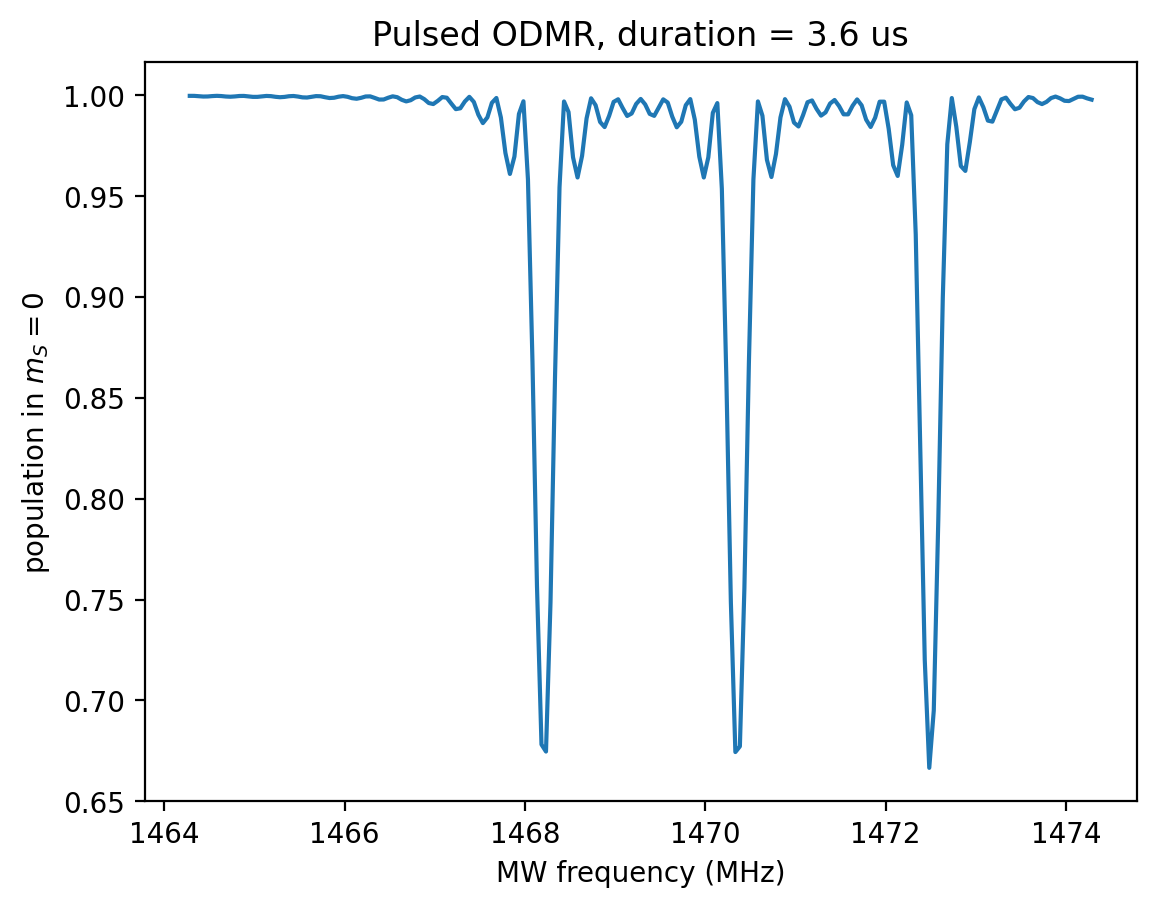

In [5]:
splitting_center = model.splitting_qubit('e')
frequencies = splitting_center + np.linspace(-5, 5, 201)  # MHz

duration_long = 3.6  # us, close to the T_2^* = 3.0 us measured by Dreau et al. (2011)
contrast_long = pulsed_odmr(model, duration_long, frequencies, initial_density_matrix)

plt.plot(frequencies, contrast_long)
plt.xlabel('MW frequency (MHz)')
plt.ylabel('population in $m_S=0$')
plt.title(f'Pulsed ODMR, duration = {duration_long} us')
plt.show()

The three dips sit at the electron splitting conditioned on each nuclear spin projection $m_I$. We can check the predicted locations directly:

In [6]:
for m_I in (-1, 0, 1):
    splitting_m_I = model.splitting_qubit('e', rest_quantum_nums={'N': m_I})
    print(f'm_I={m_I:+d}: predicted dip at {splitting_m_I:.4f} MHz')

m_I=-1: predicted dip at 1468.2099 MHz
m_I=+0: predicted dip at 1470.3566 MHz
m_I=+1: predicted dip at 1472.4917 MHz


Only one nuclear spin projection $m_I$ is resonant at each dip, so only $1/3$ of the population is driven out of $m_S=0$ there, while the other $2/3$ stays near population $1$. The predicted dip minimum is therefore

$$
P_\text{min} = \tfrac{1}{3}(0) + \tfrac{2}{3}(1) = \tfrac{2}{3},
$$

which we can compare against the simulated minimum:

In [7]:
print(f'simulated dip minimum  = {contrast_long.min():.4f}')
print(f'predicted dip minimum   = {2/3:.4f}')

simulated dip minimum  = 0.6665
predicted dip minimum   = 0.6667


## Pulse-duration-limited linewidth

A much shorter pulse delivers the same $\pi$-rotation area with proportionally higher amplitude, and its Fourier bandwidth exceeds the ~2.14 MHz hyperfine splitting &mdash; the three lines (one per $m_I$) broaden and merge. We pick `duration_short = 0.45` $\mu\text{s}$, corresponding to a Rabi frequency of about 1.1 MHz (`1 / (2 * 0.45 us)`):

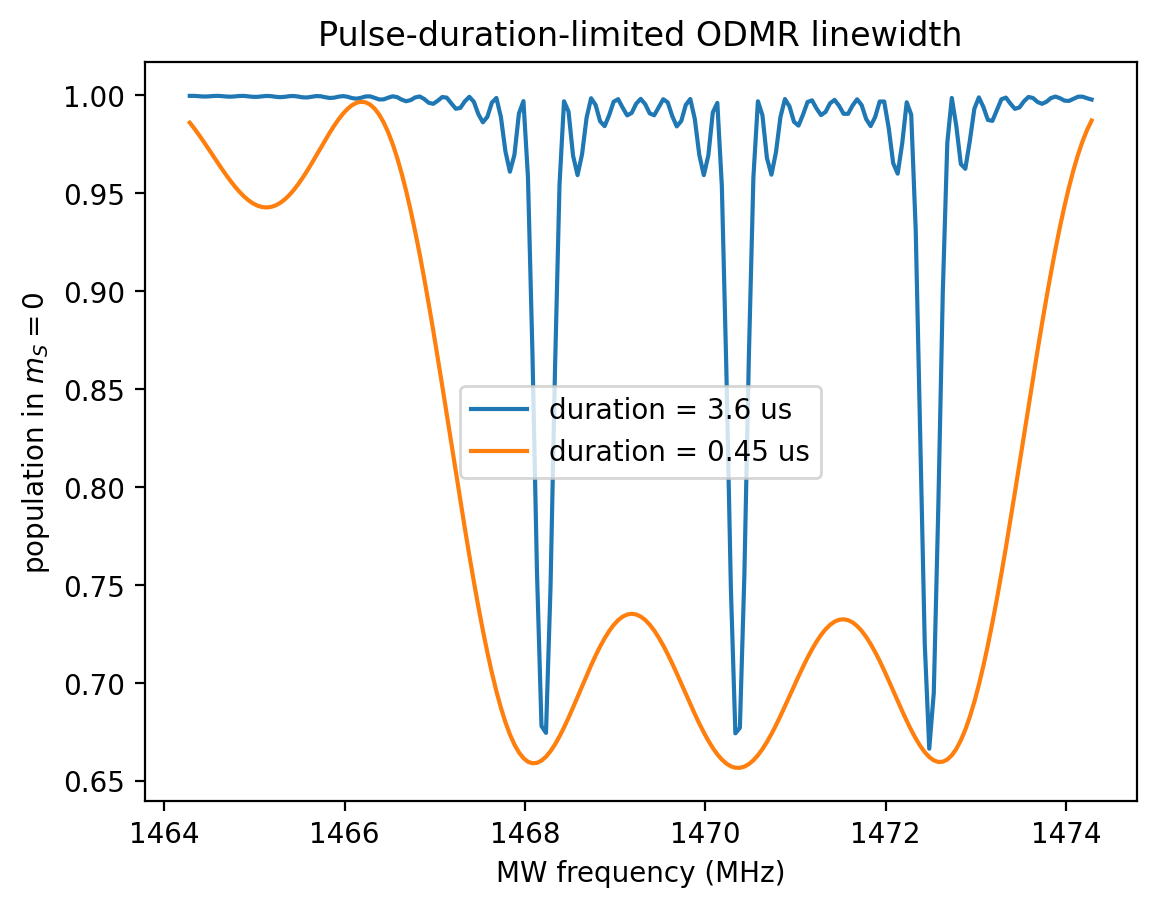

In [8]:
duration_short = 0.45  # us, a short pi-pulse well below T_2^* (Dreau et al. 2011)
contrast_short = pulsed_odmr(model, duration_short, frequencies, initial_density_matrix)

plt.plot(frequencies, contrast_long, label=f'duration = {duration_long} us')
plt.plot(frequencies, contrast_short, label=f'duration = {duration_short} us')
plt.xlabel('MW frequency (MHz)')
plt.ylabel('population in $m_S=0$')
plt.title('Pulse-duration-limited ODMR linewidth')
plt.legend()
plt.show()

In [9]:
fourier_bandwidth_short = 1 / duration_short
adjacent_hyperfine_splitting = (model.splitting_qubit('e', rest_quantum_nums={'N': 0})
                                - model.splitting_qubit('e', rest_quantum_nums={'N': -1}))

print(f'Fourier bandwidth ~ 1 / duration_short      = {fourier_bandwidth_short:.3f} MHz')
print(f'adjacent hyperfine splitting (m_I=-1 to 0)  = {adjacent_hyperfine_splitting:.3f} MHz')

Fourier bandwidth ~ 1 / duration_short      = 2.222 MHz
adjacent hyperfine splitting (m_I=-1 to 0)  = 2.147 MHz


As predicted, the Fourier bandwidth is slightly larger than the adjacent hyperfine splitting &mdash; enough to blur the three branches together into the single broadened line seen above.

This is the practical reason pulse duration must be chosen carefully in pulsed ODMR: a pulse short enough to be convenient can broaden the resonance past the hyperfine splitting, hiding structure that a longer (but still finite) pulse resolves cleanly.

This is exactly the effect exploited by Dréau *et al.* (2011): replacing continuous-wave ODMR with a resonant microwave $\pi$-pulse followed by an optimized readout pulse removes power broadening from the linewidth, since the pulse's own (finite) duration &mdash; not the drive amplitude &mdash; then sets the resolution.

**A caveat**: in the real experiment, the linewidth does not keep narrowing forever as $T_\pi$ grows. Dréau *et al.* measure the linewidth becoming Fourier-limited ($\propto 1/T_\pi$) for $T_\pi \ll T_2^*$, but then *saturating* around $\Gamma_2^* \approx 0.2$ MHz once $T_\pi \gtrsim T_2^* = 3.0$ $\mu\text{s}$, with the contrast then degrading for still-longer pulses instead of the line narrowing further. This simulation has no $T_2^*$/dephasing mechanism, so it cannot reproduce that saturation &mdash; an arbitrarily long `duration` here would keep narrowing the simulated line indefinitely. `duration_long = 3.6` $\mu\text{s}$ is chosen close to the paper's measured $T_2^*$, matching the regime where their observed saturation sets in.

## Summary

* A pulsed-ODMR spectrum is a frequency-swept $\pi$-pulse experiment, naturally expressed with the same pulse-construction tools (`add_rectangle_pulse`, `rabi_amplitude_qubit`) used throughout the tutorial series.
* A real ODMR measurement does not know the nuclear-spin state; representing it as a thermally mixed `Model.initial_density_matrix` reproduces the hyperfine-resolved triplet directly from a single frequency sweep, including the reduced ($2/3$ population, i.e. $1/3$ fractional contrast) per-line dip depth from branching over the three nuclear spin projections $m_I \in \{-1,0,+1\}$.
* The built-in `'M'` operator string symbol (paired with `'1'` for spectator spins) reads out the full-space $m_S=0$ population directly, avoiding the need to reason about qubit-subspace truncation for spins with more physical levels than their addressed qubit subspace.
* The ODMR linewidth is limited by the microwave pulse duration (Fourier/power broadening): a longer $\pi$-pulse resolves hyperfine structure that a shorter one of the same pulse area blurs together.